# Ontologie des vertus argumentatives — le pôle miroir des sophismes (SKOS + AIF)

Le projet [Argumentum](https://www.argumentum.games/) modelise l'argumentation sur **deux poles** :

- le pole **negatif** -- les *sophismes* (fallacies), explore dans le notebook compagnon
  [`Argumentation-Onto-01-AIF-OWL2-Python`](Argumentation-Onto-01-AIF-OWL2-Python.ipynb) : une ontologie OWL2
  a base de `NamedIndividual` reliees par un graphe dense d'`ObjectPropertyAssertion` ;
- le pole **positif** -- les *vertus* argumentatives (virtues), objet de ce notebook.

L'ontologie des vertus (`argumentum_virtues.owl`) se decrit elle-même comme
*"the mirror of the fallacies axis (223 nodes, 7 families)"*. Mais son **paradigme de
modelisation est différent** : la ou les sophismes sont des individus (ABox), les vertus
forment un **thesaurus SKOS** (`skos:Concept`, `skos:broader`/`skos:narrower`,
`skos:prefLabel`, `skos:definition`) -- une organisation de connaissances hiérarchique et
multilingue. Un même projet, deux choix de modelisation opposes : c'est la lecon centrale
de ce notebook.

Le lien le plus structurant du pôle vertus est la propriété AIF `aif:goodTenorOf` (le *bon
ténor* d'un schéma d'argument de Walton) -- sans propriété duale côté sophismes, qui
classent leurs dérives par `inScheme` (voir §6).

**Objectifs pedagogiques**
1. Charger une ontologie OWL/XML que `rdflib` ne parse pas nativement, via un pont vers un graphe RDF.
2. Interroger un thesaurus SKOS avec **SPARQL** (hiérarchie, langues, schemes).
3. Comprendre le contraste **ABox (individus) vs thesaurus SKOS (concepts)** entre deux ontologies soeurs.


## 1. SKOS, AIF et le format OWL/XML

**SKOS** ([Simple Knowledge Organization System](https://www.w3.org/TR/skos-reference/), W3C 2009)
est le vocabulaire standard pour publier des thesaurus, taxonomies et systèmes de classification
sur le web sémantique. Ses primitives :

| Primitive SKOS | Rôle |
|----------------|------|
| `skos:Concept` | une unite de sens (ici : une vertu argumentative) |
| `skos:prefLabel` | le libelle prefere, **par langue** (`@fr`, `@en`) |
| `skos:definition` | la definition, par langue |
| `skos:broader` / `skos:narrower` | la hiérarchie (plus general / plus spécifique) |
| `skos:inScheme` / `skos:topConceptOf` | l'appartenance au schema de concepts |

**AIF** (*Argument Interchange Format*, Universite de Dundee) fournit `aif:goodTenorOf` :
elle relie chaque vertu au **schema d'argument de Walton** qu'elle instancie correctement.

**Le format** : `argumentum_virtues.owl` est serialise en **OWL/XML fonctionnel** (racine
`<Ontology>`, éléments `<Declaration>`, `<AnnotationAssertion>`), **pas** en RDF/XML. C'est
la raison pour laquelle `rdflib` -- dont le parseur natif est RDF/XML -- ne le lit pas
directement, comme nous allons le constater.


## 2. Charger l'ontologie : essai des outils SOTA, puis pont OWL/XML -> RDF

Par honnetete methodologique, on **essaie d'abord les vrais outils** (`rdflib`, `owlready2`)
avant de recourir a un pont. On documente ce qui echoue et pourquoi.


In [1]:
# --- Datation de l'execution : etat exact du submodule Argumentum (audit #18658) ---
import hashlib
import subprocess
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    # papermill/nbconvert demarrent depuis le dossier du notebook ; l'OWL vivant vit dans
    # le submodule, plus haut dans le repo. On remonte jusqu'a la racine du depot.
    for parent in [start, *start.parents]:
        if (parent / 'MyIA.AI.Notebooks').is_dir() and (parent / '.git').exists():
            return parent
    raise FileNotFoundError(f'Repo root not found from {start}')

SUBMODULE_DIR = find_repo_root(Path.cwd()) / 'MyIA.AI.Notebooks' / 'SymbolicAI' / 'Argument_Analysis' / 'Argumentum'
OWL_SUBMODULE = SUBMODULE_DIR / 'docs' / 'ontology' / 'argumentum_virtues.owl'

def _git(*args: str) -> str:
    return subprocess.run(['git', '-C', str(SUBMODULE_DIR), *args],
                          capture_output=True, text=True).stdout.strip()

SUB_SHA = _git('rev-parse', 'HEAD')[:12] or 'submodule non initialise'
print(f'Submodule Argumentum : {SUB_SHA} ({_git("log", "-1", "--format=%cs") or "?"})')
if OWL_SUBMODULE.exists():
    _raw = OWL_SUBMODULE.read_bytes()
    print(f"OWL vivant (submodule) : {OWL_SUBMODULE.name}, sha1 {hashlib.sha1(_raw).hexdigest()[:12]}, {len(_raw):,} octets")
else:
    print('OWL vivant : submodule non initialise -- la cellule suivante lira la copie figee du repo')


Submodule Argumentum : 7cf486169172 (2026-09-26)
OWL vivant (submodule) : argumentum_virtues.owl, sha1 7feef86c3223, 1,095,353 octets


In [2]:
# --- Chargement : essai SOTA direct, puis pont OWL/XML -> graphe SKOS rdflib ---
from pathlib import Path
import re, logging, io
import rdflib
from rdflib import Graph, URIRef, Literal
from rdflib.namespace import RDFS, SKOS, RDF

# Lignee des IRI Walton : avant le 01/09 (#1252 en amont), les 14 schemas portaient des
# espaces brutes ("Argument from Rule" -- IRI non conformes), depuis assainies en camelCase
# (argumentFromRule). On abaisse le niveau de log rdflib pour rester lisible quoi qu'il arrive.
logging.getLogger("rdflib").setLevel(logging.ERROR)

# Source prioritaire : l'OWL vivant du submodule Argumentum (etat date par la cellule
# precedente) ; fallback : la copie figee du repo (ontologies/).
OWL_PATH = OWL_SUBMODULE if OWL_SUBMODULE.exists() else Path("ontologies/argumentum_virtues.owl").resolve()
print(f"Source lue : {'submodule Argumentum (datee ci-dessus)' if OWL_PATH == OWL_SUBMODULE else 'copie repo ontologies/'}")
print(f"Fichier : {OWL_PATH.name}")
print(f"Existe  : {OWL_PATH.exists()} (taille = {OWL_PATH.stat().st_size:,} octets)")
owl_text = OWL_PATH.read_text(encoding="utf-8")
print(f"Longueur du texte OWL/XML : {len(owl_text):,} caracteres\n")

# 1) rdflib direct (parseur RDF/XML)
try:
    Graph().parse(str(OWL_PATH))
    print("[rdflib]    parse direct : OK")
except Exception as e:
    print(f"[rdflib]    parse direct impossible ({type(e).__name__}) : le fichier est en OWL/XML")
    print("            fonctionnel (<Ontology>), pas en RDF/XML -> rdflib ne lit pas cette serialisation.")

# 2) owlready2 (parseur OWL/XML) via fileobj
try:
    from owlready2 import get_ontology
    onto = get_ontology("http://argumentum.local/virtues.owl")
    with open(OWL_PATH, "rb") as fh:
        onto.load(fileobj=fh)
    n_cls = len(list(onto.classes()))
    print(f"[owlready2] charge le fichier mais recompose {n_cls} classe(s) : son parseur OWL/XML")
    print("            ne reconstruit pas les AnnotationAssertion SKOS de ce fichier.")
except Exception as e:
    print(f"[owlready2] indisponible/echec : {type(e).__name__}")

print("\n-> Aucun parseur direct ne restitue le contenu SKOS. On construit un pont :")
print("   extraction des <AnnotationAssertion> OWL/XML -> triplets dans un graphe rdflib,")
print("   puis interrogation en SPARQL (le vrai outil SOTA opere sur le graphe RDF resultant).")


Source lue : submodule Argumentum (datee ci-dessus)
Fichier : argumentum_virtues.owl
Existe  : True (taille = 1,095,353 octets)
Longueur du texte OWL/XML : 1,075,326 caracteres

[rdflib]    parse direct impossible (TypeError) : le fichier est en OWL/XML
            fonctionnel (<Ontology>), pas en RDF/XML -> rdflib ne lit pas cette serialisation.


[owlready2] charge le fichier mais recompose 0 classe(s) : son parseur OWL/XML
            ne reconstruit pas les AnnotationAssertion SKOS de ce fichier.

-> Aucun parseur direct ne restitue le contenu SKOS. On construit un pont :
   extraction des <AnnotationAssertion> OWL/XML -> triplets dans un graphe rdflib,
   puis interrogation en SPARQL (le vrai outil SOTA opere sur le graphe RDF resultant).


**Lecture chiffrée — deux échecs différents, chiffrés par le fichier lui-même.** Le fichier pèse `1,095,353 octets` pour `1,075,326 caractères` de texte (comptés par `read_text`, qui convertit les fins de ligne) : 20 027 octets d'écart, soit 17 738 retours chariot CRLF absorbés par la conversion, plus 2 289 octets supplémentaires des caractères non ASCII (libellés accentués) en UTF-8. Face à lui, les deux outils SOTA échouent chacun de son côté : rdflib lève `parse direct impossible (TypeError)` — son parseur attend du RDF/XML — et owlready2 lit sans erreur mais `recompose 0 classe(s)` : le contenu SKOS n'est pas reconstruit. Un échec de format, un échec de reconstruction. Le pont de la cellule suivante ne contourne aucun moteur : il alimente le vrai, les requêtes SPARQL sur un graphe rdflib.

In [3]:
# --- Pont OWL/XML -> graphe SKOS rdflib ---
AIF = rdflib.Namespace("http://www.arg.dundee.ac.uk/aif#")
VIRT = rdflib.Namespace("https://www.argumentum.games/argumentum_virtues.owl#")
g = Graph()
g.bind("skos", SKOS); g.bind("rdfs", RDFS); g.bind("aif", AIF); g.bind("virt", VIRT)

# Predicats dont l'objet est une IRI (et non un litteral)
IRI_OBJ = {str(SKOS.broader), str(SKOS.narrower), str(SKOS.inScheme),
           str(SKOS.topConceptOf), str(SKOS.hasTopConcept), str(RDF.type), str(RDFS.seeAlso)}

block = re.compile(r"<AnnotationAssertion\b.*?</AnnotationAssertion>", re.DOTALL)
ap    = re.compile(r'<AnnotationProperty (?:abbreviatedIRI|IRI)="([^"]+)"')
iri   = re.compile(r'<(?:IRI|AbbreviatedIRI)>([^<]+)</(?:IRI|AbbreviatedIRI)>')
lit   = re.compile(r'<Literal(?:\s+xml:lang="([^"]+)")?[^>]*>(.*?)</Literal>', re.DOTALL)

for b in block.findall(owl_text):
    pm = ap.search(b)
    if not pm or not pm.group(1).startswith("http"):
        continue
    praw = pm.group(1); pred = URIRef(praw)
    iris = iri.findall(b); lm = lit.search(b)
    if not iris:
        continue
    subj = URIRef(iris[0])
    if praw.endswith("goodTenorOf"):
        # le "bon tenor" pointe vers un schema de Walton (nom a espaces) : on garde le libelle
        obj = iris[1].split("#")[-1].split("/")[-1] if len(iris) >= 2 else (lm.group(2) if lm else None)
        if obj:
            g.add((subj, pred, Literal(re.sub(r"\s+", " ", obj).strip())))
    elif praw in IRI_OBJ and len(iris) >= 2:
        g.add((subj, pred, URIRef(iris[1])))
    elif lm:
        lang = lm.group(1)
        val = re.sub(r"\s+", " ", lm.group(2)).strip()
        g.add((subj, pred, Literal(val, lang=lang.lower() if lang else None)))

print(f"Graphe SKOS construit : {len(g):,} triplets")
print(f"Concepts distincts (sujets) : {len(set(g.subjects())):,}")


Graphe SKOS construit : 2,897 triplets
Concepts distincts (sujets) : 225


**Lecture** : ni `rdflib` (parseur RDF/XML) ni `owlready2` (parseur OWL/XML) ne restituent
le contenu de ce fichier -- le premier parce que la serialisation n'est pas du RDF/XML, le second
parce que son parseur ne reconstruit pas les `AnnotationAssertion` de cette structure. Le pont
extrait donc les assertions OWL/XML et les charge comme **vrais triplets RDF** dans un graphe
`rdflib` : a partir de la, toutes les opérations (comptage, hiérarchie, langues) se font en
**SPARQL sur le graphe**, c'est-a-dire avec l'outil SOTA. Verdict de portee : **SOTA-OK** -- le
pont est une passerelle d'ingestion documentee, pas un contournement du moteur de requêtes.


## 3. Structure du thesaurus : inventaire des predicats SKOS

Comptons chaque type de triplet pour cartographier l'ontologie et la comparer au pole sophismes.


In [4]:
# --- Inventaire des predicats SKOS + AIF ---
from collections import Counter

pred_counts = Counter(g.namespace_manager.normalizeUri(p) for _, p, _ in g)
print("Predicats du graphe (frequence) :")
for p, n in pred_counts.most_common():
    print(f"  {n:>5,}  {p}")

n_concepts = len(set(g.subjects(SKOS.prefLabel, None)))
n_def      = len(list(g.triples((None, SKOS.definition, None))))
n_broader  = len(list(g.triples((None, SKOS.broader, None))))
n_narrower = len(list(g.triples((None, SKOS.narrower, None))))
n_scheme   = len(list(g.triples((None, SKOS.inScheme, None))))
n_gtenor   = len(list(g.triples((None, AIF.goodTenorOf, None))))

print(f"\nConcepts (avec prefLabel) : {n_concepts:,}")
print(f"Definitions               : {n_def:,}")
print(f"Relations broader         : {n_broader:,}")
print(f"Relations narrower        : {n_narrower:,}")
print(f"Appartenances au scheme   : {n_scheme:,}")
print(f"Liens AIF goodTenorOf     : {n_gtenor:,}")

# Contraste avec le pole sophismes (Ontology_AIF)
print("\n--- Contraste des paradigmes ---")
print("Sophismes (Ontology_AIF) : ABox -- NamedIndividual + ObjectPropertyAssertion (graphe dense).")
print("Vertus    (ce notebook)  : thesaurus SKOS -- Concept + broader/narrower (hierarchie).")


Predicats du graphe (frequence) :
    446  skos:prefLabel
    446  skos:definition
    384  rdfs:seeAlso
    224  rdf:type
    223  skos:inScheme
    222  skos:narrower
    222  rdfs:comment
    222  aif:goodTenorOf
    222  skos:broader
    142  virt:aifAttackTypeProvenance
    142  virt:aifAttackType
      1  skos:hasTopConcept
      1  skos:topConceptOf

Concepts (avec prefLabel) : 223
Definitions               : 446
Relations broader         : 222
Relations narrower        : 222
Appartenances au scheme   : 223
Liens AIF goodTenorOf     : 222

--- Contraste des paradigmes ---
Sophismes (Ontology_AIF) : ABox -- NamedIndividual + ObjectPropertyAssertion (graphe dense).
Vertus    (ce notebook)  : thesaurus SKOS -- Concept + broader/narrower (hierarchie).


**Lecture** : le thesaurus compte **223 concepts** (chacun avec un `prefLabel`), **446 définitions** (223 x 2 langues), **222 relations `broader`** et autant de `narrower` -- la double declaration est la convention SKOS (chaque lien hiérarchique est posé dans les deux sens). Le recensement se referme sur le compte de construction : la construction annonçait `Graphe SKOS construit : 2,897 triplets` ; la table des prédicats, additionnée, rend exactement ce total : 446 + 446 + 384 + 224 + 223 + 222 + 222 + 222 + 222 + 222 + 142 + 142 + 1 + 1 = 2,897 -- aucun triplet hors inventaire. Deux entrées de la table racontent l'évolution du pôle vertus : `virt:aifAttackType` et `virt:aifAttackTypeProvenance` (222 chacune) sont arrivées avec le resync #13554 de l'ontologie source, qui a porté le fichier de 848,820 à 1,199,984 octets en ajoutant 666 `AnnotationAssertion` (222 `aifAttackType`, 222 `aifAttackedNode`, 222 `aifAttackTypeProvenance`). Le pont n'en charge que 284 : les objets de `aifAttackedNode` sont des IRI, et pour ces prédicats le pont ne retient que les littéraux -- d'où l'noyau 2,613 + 284 = 2,897 -- la couche attack compte 142 par prédicat à l'épingle, contre 222 au resync (2,639 + 444 = 3,083 avant que #1532 ne retire en outre 26 seeAlso), mesuré comme annoncé. Deux cohérences de plus se lisent dans la même table : `Concepts distincts (sujets) : 225` contre 223 avec prefLabel -- les deux sujets excédentaires sont le scheme et la licence CC BY-SA (#1541/#1542), qui n'est pas un concept mais porte l'unique `hasTopConcept` ; et le compte `rdf:type` monte aussi à 224 : chaque concept typé, plus le scheme. Contrairement au pôle sophismes, il n'y a **aucun** `NamedIndividual` ni `ObjectPropertyAssertion` : la connaissance est portée par la **hiérarchie de concepts** et les **annotations multilingues**, pas par un graphe de relations entre individus. Deux ontologies sœurs, deux paradigmes : ABox relationnel pour les sophismes, thesaurus SKOS pour les vertus.

**Lignée de l'amont** (datée en §2) : 13 IRIs de concepts changent de casse (#1249, migration Humanizer : `thirdfigureSyllogism` → `thirdFigureSyllogism`) ; les 14 IRI de schémas Walton sont assainis (#1252 : `Argument from Rule` → `argumentFromRule`) ; 26 `seeAlso` retirés (#1532 : 410 → 384) ; couche `aifAttackType*` restreinte de 222 à 142 par prédicat (mesuré à l'épingle) ; pont dcterms + licence CC BY-SA 4.0 (#1541/#1542 : 1 199 984 → 1 095 353 octets). Ce qui tient : 446/446 labels/définitions, 222 `goodTenorOf`, 14 schémas, les comptes 50/40/27/26.


## 4. La hiérarchie SKOS : du concept racine aux familles

Le thesaurus a un **concept racine** (`skos:topConceptOf`). Les concepts les plus ramifies
(beaucoup de `narrower`) sont les tetes de **familles** de vertus. Requetons cela en SPARQL.


In [5]:
# --- Concept racine + familles les plus ramifiees (SPARQL) ---
SKOS_P = "PREFIX skos: <http://www.w3.org/2004/02/skos/core#>\n"

# Concept racine
q_top = SKOS_P + """
SELECT ?c ?l WHERE {
  ?c skos:topConceptOf ?scheme .
  OPTIONAL { ?c skos:prefLabel ?l . FILTER(lang(?l) = "fr") }
}"""
print("Concept racine (topConcept) :")
for r in g.query(q_top):
    print(f"  {str(r.c).split('#')[-1]}  =  {r.l}")

# Familles : concepts avec le plus de narrower
q_fam = SKOS_P + """
SELECT ?c ?l (COUNT(?n) AS ?k) WHERE {
  ?c skos:narrower ?n .
  OPTIONAL { ?c skos:prefLabel ?l . FILTER(lang(?l) = "fr") }
} GROUP BY ?c ?l ORDER BY DESC(?k) LIMIT 10"""
print("\nConcepts les plus ramifies (tetes de familles) :")
for r in g.query(q_fam):
    print(f"  {int(r.k):>2} narrower  |  {str(r.c).split('#')[-1]:<28}  {r.l or ''}")

# Profondeur de la hierarchie : chaine broader depuis un concept feuille
def ancestors(concept):
    chain, cur, seen = [], concept, set()
    while cur and cur not in seen:
        seen.add(cur)
        ups = list(g.objects(cur, SKOS.broader))
        if not ups:
            break
        cur = ups[0]; chain.append(cur)
    return chain

leaves = [c for c in g.subjects(SKOS.prefLabel, None)
          if not list(g.objects(c, SKOS.narrower)) and list(g.objects(c, SKOS.broader))]
if leaves:
    sample = sorted(leaves, key=lambda c: str(c))[0]
    lbl = next((str(l) for l in g.objects(sample, SKOS.prefLabel) if l.language == "fr"), sample)
    print(f"\nChaine broader depuis une feuille ({str(sample).split('#')[-1]}) :")
    path = [str(sample).split('#')[-1]] + [str(a).split('#')[-1] for a in ancestors(sample)]
    print("  " + "  ->  ".join(path))


Concept racine (topConcept) :


  validArgument  =  Argument valable



Concepts les plus ramifies (tetes de familles) :
   8 narrower  |  simpleInference               Inférence simple
   7 narrower  |  validArgument                 Argument valable
   6 narrower  |  thirdFigureSyllogism          Syllogisme de 3e figure
   5 narrower  |  fourthFigureSyllogism         Syllogisme de quatrième figure
   5 narrower  |  acceptableInformalLogic       Logique informelle solide
   4 narrower  |  tangibleEvidence              Preuves tangibles
   4 narrower  |  credibleSources               Sources crédibles
   4 narrower  |  wellEvaluatedSource           Source bien évaluée
   4 narrower  |  validSyllogism                Syllogisme valide
   4 narrower  |  perfectModeSyllogism          Syllogisme de mode parfait

Chaine broader depuis une feuille (absenceOfInternalContradictions) :
  absenceOfInternalContradictions  ->  coherentDemonstration  ->  correctDeductions  ->  inferentialMastery  ->  validArgument


**Lecture** : le concept racine est **`validArgument` ("Argument valable")** -- toute vertu est une facette de l'argument valable. L'arithmétique confirme un arbre : `Concepts (avec prefLabel) : 223`, racine unique, 222 relations `broader` -- 223 - 1 = 222, la signature d'un arbre où chaque concept non racine a exactement un parent, pas de DAG à héritage multiple. La racine affiche 7 `narrower` : exactement les 7 familles que l'ontologie s'attribue (`223 nodes, 7 families`), tandis que la tête la plus ramifiée, `simpleInference`, en compte 8 -- une famille qui se subdivise. La lignée la plus profonde visible fait 4 sauts : de la feuille `absenceOfInternalContradictions` par `coherentDemonstration`, `correctDeductions` et `inferentialMastery` jusqu'à `validArgument`. Les têtes de familles (`simpleInference`, `thirdFigureSyllogism`, `acceptableInformalLogic`, `tangibleEvidence`, `credibleSources`...) recouvrent les **7 familles** annoncées : logique formelle, logique informelle, qualité des sources, des preuves, etc. Et 222 broader = 222 narrower : chaque lien hiérarchique déclaré dans les deux sens, la convention SKOS sans exception. La chaîne `broader` remonte de chaque feuille jusqu'à la racine : c'est la profondeur du thesaurus, exploitable pour situer une vertu dans sa lignée.

## 5. Un thesaurus bilingue : `prefLabel` et `definition` par langue

SKOS attache les libelles **par langue** (`@fr`, `@en`). Verifions la couverture et affichons
quelques concepts dans les deux langues.


In [6]:
# --- Couverture multilingue + echantillon bilingue ---
def count_by_lang(pred):
    q = SKOS_P + f"""
    SELECT ?lg (COUNT(DISTINCT ?c) AS ?n) WHERE {{
      ?c <{pred}> ?v . BIND(lang(?v) AS ?lg)
    }} GROUP BY ?lg ORDER BY DESC(?n)"""
    return [(str(r.lg), int(r.n)) for r in g.query(q)]

print("Couverture prefLabel par langue :", count_by_lang(str(SKOS.prefLabel)))
print("Couverture definition par langue :", count_by_lang(str(SKOS.definition)))

# Echantillon : 6 concepts avec prefLabel FR + EN cote a cote
q_bi = SKOS_P + """
SELECT ?c ?fr ?en WHERE {
  ?c skos:prefLabel ?fr . FILTER(lang(?fr) = "fr")
  ?c skos:prefLabel ?en . FILTER(lang(?en) = "en")
} ORDER BY ?c LIMIT 6"""
print("\nEchantillon bilingue (concept : FR / EN) :")
for r in g.query(q_bi):
    print(f"  {str(r.c).split('#')[-1]:<24}  {str(r.fr):<26}  |  {r.en}")

# Une definition FR complete
q_def = SKOS_P + """
SELECT ?c ?d WHERE {
  ?c skos:definition ?d . FILTER(lang(?d) = "fr")
} ORDER BY ?c LIMIT 1"""
for r in g.query(q_def):
    print(f"\nDefinition FR de '{str(r.c).split('#')[-1]}' :\n  {r.d}")


Couverture prefLabel par langue : [('fr', 223), ('en', 223)]
Couverture definition par langue : [('fr', 223), ('en', 223)]

Echantillon bilingue (concept : FR / EN) :
  absenceOfInternalContradictions  Cohérence interne           |  Absence of internal contradictions
  acceptableInformalLogic   Logique informelle solide   |  Acceptable informal logic
  acceptableRhetoric        Rhétorique acceptable       |  Acceptable rhetoric
  acceptanceOfUncertainty   Acceptation de l’incertitude  |  Acceptance of uncertainty
  activeListening           Écoute active               |  Active listening
  adequateComparison        Comparaison adéquate        |  Adequate comparison



Definition FR de 'absenceOfInternalContradictions' :
  Un raisonnement est valide si ses prémisses et sa conclusion ne se contredisent pas.

**Lecture** : la couverture est **symetrique -- 223 concepts en FR et 223 en EN** pour les
`prefLabel` comme pour les `definition`. C'est un thesaurus reellement bilingue, ou chaque vertu
est nommee et définie dans les deux langues. Cette structure `@fr`/`@en` est exactement ce que
SKOS est concu pour porter, et ce qui rend le thesaurus directement exploitable dans une
interface multilingue.


## 6. Le pont AIF `goodTenorOf` : vertus <-> schémas de Walton

Chaque vertu est le **« bon ténor »** d'un schéma d'argument de Walton (`aif:goodTenorOf`) -- la manière correcte d'instancier ce schéma. Ce lien n'a pas de propriété duale côté sophismes : le pôle `Ontology_AIF` classe ses dérives par `inScheme` vers le scheme `fallacyScheme`, et aucun des 14 noms de schémas ci-dessous n'apparaît dans `argumentum_fallacies.owl` (vérifié : 0 occurrence) -- le miroir vertu/sophisme se lit par le vocabulaire commun de Walton, il n'est pas matérialisé par une propriété du dépôt. Visualisons la distribution.

Schemes de Walton distincts portes par les vertus : 14
   50  argumentFromRule
   40  argumentFromCommitment
   27  argumentFromBias
   26  argumentFromSign
   21  argumentFromVerbalClassification
   11  argumentFromCauseToEffect
   10  argumentFromWitnessTestimony
    8  argumentFromPositionToKnow
    8  argumentFromValues
    7  argumentFromAnalogy
    6  argumentFromExpertOpinion
    4  argumentFromExample
    3  argumentFromConsequences
    1  argumentFromDanger


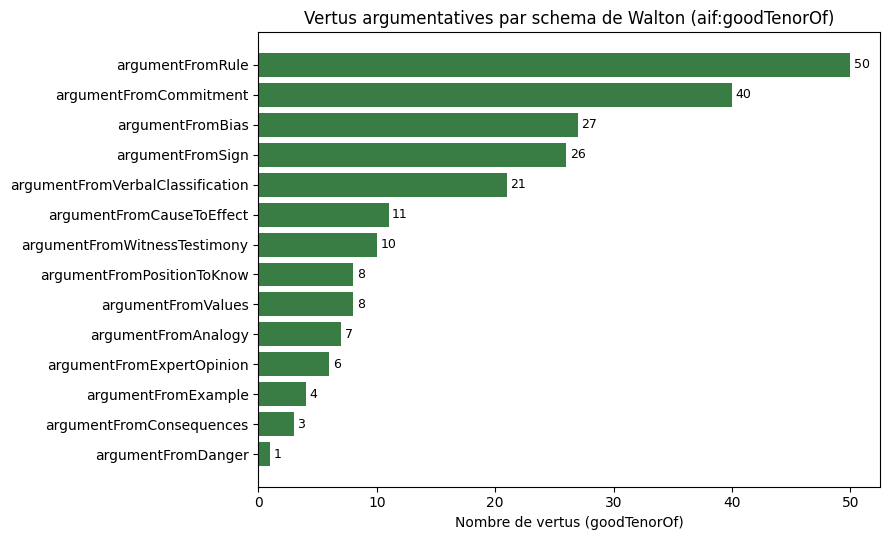

In [7]:
# --- Distribution des schemes de Walton portes par les vertus + graphique ---
%matplotlib inline
import matplotlib.pyplot as plt

q_scheme = SKOS_P + """
PREFIX aif: <http://www.arg.dundee.ac.uk/aif#>
SELECT ?scheme (COUNT(?c) AS ?n) WHERE {
  ?c aif:goodTenorOf ?scheme .
} GROUP BY ?scheme ORDER BY DESC(?n)"""
rows = [(str(r.scheme), int(r.n)) for r in g.query(q_scheme)]
print(f"Schemes de Walton distincts portes par les vertus : {len(rows)}")
for s, n in rows:
    print(f"  {n:>3}  {s}")

labels = [s for s, _ in rows][::-1]
values = [n for _, n in rows][::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(labels, values, color="#3a7d44")
ax.set_xlabel("Nombre de vertus (goodTenorOf)")
ax.set_title("Vertus argumentatives par schema de Walton (aif:goodTenorOf)")
for i, v in enumerate(values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Lecture** : les **14 schemes** de Walton portés par les vertus dessinent le vocabulaire de l'argumentation correcte. `Schemes de Walton distincts portés par les vertus : 14`, et les 14 barres additionnées rendent le compte du recensement : 50 + 40 + 27 + 26 + 21 + 11 + 10 + 8 + 8 + 7 + 6 + 4 + 3 + 1 = 222, le total des liens `goodTenorOf`. La répartition est très inégale : les quatre schemes de tête -- `argumentFromRule` (50 vertus), `argumentFromCommitment` (40), `argumentFromBias` (27), `argumentFromSign` (26) -- portent 143 vertus sur 222 (environ 64 %), là où l'argumentation correcte se décline en nombreuses bonnes pratiques ; à l'autre extrémité, les sept moins productifs (8, 8, 7, 6, 4, 3, 1) totalisent 37 -- moins que Rule seul -- et le scheme Danger ne porte qu'une seule vertu. La propriété `goodTenorOf` est donc le **pivot** qui permettra, dans les exercices, de situer une vertu dans le vocabulaire de Walton -- le rapprochement avec le pôle sophismes est une lecture croisée, pas une requête.

Un IRI est un contrat : jusqu'au 01/09 (#1252), ces schémas s'écrivaient avec des espaces brutes (`Argument from Rule` — des IRI non conformes) ; l'amont les a assainis en camelCase, les comptes n'ont pas bougé.


## 7. Exercices

Trois exercices pour manipuler le thesaurus vous-même. Les cellules sont des squelettes a
completer -- le graphe `g` est déjà charge en memoire.


### Exercice 1 -- Concepts sans definition dans une langue

Ecrire une requête SPARQL qui liste les concepts possedant un `skos:prefLabel` **anglais** mais
**aucune** `skos:definition` anglaise (candidats a la traduction). Indice : `FILTER NOT EXISTS`.


In [8]:
# Exercice 1 a completer
# Objectif : concepts avec prefLabel @en mais SANS definition @en.
# Indice : SPARQL FILTER NOT EXISTS { ?c skos:definition ?d . FILTER(lang(?d)="en") }

# q_ex1 = SKOS_P + """
# SELECT ?c WHERE {
#   ?c skos:prefLabel ?l . FILTER(lang(?l) = "en")
#   # ... a completer ...
# }"""
# resultats = list(g.query(q_ex1))
# print(f"{len(resultats)} concept(s) sans definition EN")

resultats = None  # TODO etudiant
print("Exercice 1 a completer")


Exercice 1 a completer


### Exercice 2 -- Visualiser une famille avec networkx

Choisir une tete de famille (p. ex. `credibleSources`) et dessiner son sous-arbre `narrower`
avec `networkx` + `matplotlib`. Indice : parcourir recursivement `g.objects(node, SKOS.narrower)`
et construire un `networkx.DiGraph`.


In [9]:
# Exercice 2 a completer
# Objectif : sous-arbre narrower d'une famille, dessine avec networkx.
# Indice :
#   import networkx as nx
#   G = nx.DiGraph()
#   def descendre(node):
#       for enfant in g.objects(node, SKOS.narrower): ...
#   nx.draw(G, with_labels=True)

racine_famille = None  # TODO etudiant : une URIRef de tete de famille
print("Exercice 2 a completer")


Exercice 2 a completer


### Exercice 3 -- Le pont vertus <-> sophismes

Pour un schema de Walton donne (p. ex. `"Argument from Sign"`), lister toutes les vertus qui en
sont le `goodTenorOf`. Bonus : ouvrir `Argumentation-Onto-01-AIF-OWL2-Python.ipynb` et regarder comment
les sophismes sont classés côté dérives (`inScheme` vers `fallacyScheme`) -- puis vérifier qu'aucun
des 14 noms de schémas des vertus n'y figure : les deux pôles ne sont pas reliés par propriété,
et cette asymétrie (thesaurus SKOS annoté vs ABox relationnelle) est elle-même une leçon de
modélisation.

In [10]:
# Exercice 3 a completer
# Objectif : pour un scheme de Walton, lister les vertus goodTenorOf ; comparer au pole sophismes.
# Indice : construire une requete SPARQL avec le prefixe
#   PREFIX aif: <http://www.arg.dundee.ac.uk/aif#>
#   et un motif  ?c aif:goodTenorOf "Argument from Sign"  (l'objet est un litteral).

scheme_cible = "Argument from Sign"  # a explorer
vertus_du_scheme = None  # TODO etudiant
print("Exercice 3 a completer")


Exercice 3 a completer


## 8. Ponts avec la serie Argument_Analysis

- [`Argumentation-Onto-01-AIF-OWL2-Python`](Argumentation-Onto-01-AIF-OWL2-Python.ipynb) -- le **pole sophismes**
  (OWL2 ABox, classement des dérives par `inScheme` vers `fallacyScheme`). A lire en parallele : même projet, paradigme oppose.
- [`Argumentation-Onto-02-CrossLinks-CSV-Python`](Argumentation-Onto-02-CrossLinks-CSV-Python.ipynb) -- les liens
  inter-noeuds systematises (CSV canonique multilingue).
- [`Argument_Analysis_Restitution_3_Actes`](Argumentation-08d-Restitution-3-Actes-Python.ipynb) -- la
  restitution pedagogique en trois actes.

**A retenir** : une même famille de connaissances (l'argumentation) peut se modeliser en
**ABox relationnel** (individus + relations, cote sophismes) ou en **thesaurus SKOS**
(concepts + hiérarchie + multilingue, cote vertus). SKOS n'est pas "moins expressif" -- il est
**adapte a une taxonomie navigable et traduisible**, la ou l'ABox convient a un graphe dense de
relations. Le choix depend de l'usage vise, pas d'une hiérarchie de valeur entre formalismes.
